# 08-Agentic RAG (CRAG & Self-RAG)

In Section 13, we engineered Enterprise Retrieval-Augmented Generation (RAG) pipelines. We built Vector Databases and tuned Hybrid Search to feed context to our LLMs.

However, standard RAG architectures are **Mathematically Linear and Passive**:


$$q \rightarrow \text{Retrieve}(z) \rightarrow \text{Generate}(a)$$

If the Vector Database fails to retrieve relevant documents (due to a poor user query or a vocabulary mismatch), the linear pipeline blindly passes that irrelevant garbage context to the LLM. The LLM, forced to answer, hallucinates.

To achieve production-grade reliability, we must fuse the retrieval physics of Section 13 with the cyclic StateGraph orchestration of Section 14. This creates **Agentic RAG** (specifically, frameworks like Corrective RAG [CRAG] and Self-RAG).

An Agentic RAG system evaluates its own retrieved documents. If they are irrelevant, it refuses to answer, rewrites the user's query autonomously, and loops back to search the database again.

Let's set up our environment to engineer autonomous retrieval loops.

In [8]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph pydantic matplotlib seaborn
from typing import List, TypedDict
from pydantic import BaseModel, Field
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langgraph.graph import StateGraph, START, END
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import time

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Agentic RAG Environment Ready.")

✅ Systems Architecture & Agentic RAG Environment Ready.


# 1. The Mathematics of Corrective Retrieval

In Agentic RAG, we introduce a **Grader Node** equipped with a strict Pydantic boolean classifier.

Let $q_t$ be the query at iteration $t$, and $Z = \{z_1, z_2, \dots, z_k\}$ be the set of retrieved documents.
Before generation, the LLM mathematically scores the relevance of the documents:


$$f_{grade}(q_t, z_i) \in \{0, 1\}$$

If $\sum f_{grade}(q_t, z_i) == 0$ (all retrieved documents are irrelevant), the pipeline activates the **Rewriter Node** ($\pi_{rewrite}$). It uses the LLM to analyze why the search failed, generates a new optimized query $q_{t+1}$, and mathematically mutates the graph's trajectory back to the Vector Database:


$$q_{t+1} = \pi_{rewrite}(q_t)$$

$$S_{t+1} = \text{Retrieve}(q_{t+1})$$

# 2. Architecting the CRAG StateGraph

Let's build a real, executable Corrective RAG pipeline.
We will purposefully ingest a tiny database about "Project Quantum". We will then ask a terrible, vague user query ("What's the launch date for the new thing?").

Standard RAG would fail. Our Agentic RAG will retrieve garbage, grade it as a failure, rewrite the query, and search again.

In [12]:
# --- 🧠 The Agentic RAG Execution Engine ---

# 1. Initialize the Local Vector Database (The Physical Memory)
print("--- 🗄️ Initializing Vector Space ---")
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = InMemoryVectorStore(embeddings)

# Ingesting our Enterprise Documents
docs = [
    Document(page_content="The company cafeteria serves pizza on Fridays.", metadata={"source": "HR"}),
    Document(page_content="Project Quantum is a classified 10,000-GPU cluster in Iceland, launching in Q4 2026.", metadata={"source": "Engineering"}),
    Document(page_content="Sarah Jenkins is the CEO of Nexus Dynamics.", metadata={"source": "Corporate"})
]
vectorstore.add_documents(docs)
# Increased k to 2 to give the rewriter a higher mathematical probability of finding the target
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

# 2. Define the Pydantic Schema for the Grader Node
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

# Initialize Local Models
llm = ChatOllama(model="llama3.2", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 3. Define the Mathematical State
class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[Document]
    loop_count: int

# 4. Define the Computational Nodes
def retrieve_node(state: GraphState):
    """Physically queries the Vector Database."""
    print(f"\n   🔍 [NODE: Retriever] Executing Dense Search for: '{state['question']}'")
    documents = retriever.invoke(state["question"])
    return {"documents": documents, "loop_count": state.get("loop_count", 0) + 1}

def grade_documents_node(state: GraphState):
    """Uses Pydantic Coercion to evaluate relevance with safety fallbacks."""
    print("   🧐 [NODE: Grader] Evaluating Document Relevance...")
    question = state["question"]
    documents = state["documents"]
    
    filtered_docs = []
    for d in documents:
        # Stricter prompt to prevent small model hallucination outside JSON
        prompt = f"""You are a strict grader. 
        Retrieved document: {d.page_content} 
        User question: {question} 
        Does the document contain the answer? 
        Respond ONLY with 'yes' or 'no'."""
        
        try:
            grade: GradeDocuments = structured_llm_grader.invoke([HumanMessage(content=prompt)])
            
            if grade.binary_score.lower() == "yes":
                print("      -> Result: ✅ RELEVANT. Preserving document.")
                filtered_docs.append(d)
            else:
                print("      -> Result: ❌ IRRELEVANT. Discarding document.")
                
        except Exception as e:
            # Prevents LangChain parser retry loops from crashing/hanging the system
            print(f"      -> ⚠️ Parsing Error/Timeout. Forcing to IRRELEVANT to prevent crash.")
            
        # Allows Ollama VRAM to clear the previous request before invoking the next
        time.sleep(1)
            
    return {"documents": filtered_docs}

def generate_node(state: GraphState):
    """Standard RAG Synthesis."""
    print("   ✍️ [NODE: Generator] Synthesizing Final Answer...")
    context = "\n".join([d.page_content for d in state["documents"]])
    prompt = f"Answer the question based strictly on the context.\nQuestion: {state['question']}\nContext: {context}"
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"generation": response.content}

def rewrite_query_node(state: GraphState):
    """Autonomously hallucinates a better query."""
    print("   🔄 [NODE: Rewriter] Vector DB failed. Rewriting user query...")
    prompt = f"The user asked a vague question: '{state['question']}'. Rewrite it to be a specific, optimized search query for an engineering database. Return ONLY the new query."
    response = llm.invoke([HumanMessage(content=prompt)])
    optimized_query = response.content.strip().strip('"')
    print(f"      -> New Query Formulated: '{optimized_query}'")
    return {"question": optimized_query}

# 5. Define the Conditional Routing Logic
def decide_to_generate(state: GraphState):
    """Evaluates the State to determine the structural graph path."""
    print("   🔀 [ROUTER] Deciding next topological step...")
    filtered_documents = state["documents"]
    
    # Recursion Safety Governor
    if state["loop_count"] >= 3:
        print("      -> Recursion Limit Hit. Forcing Generation.")
        return "generate"
        
    if not filtered_documents:
        print("      -> Zero relevant documents. Routing to Rewriter.")
        return "rewrite_query"
    else:
        print("      -> Valid documents found. Routing to Generator.")
        return "generate"

# 6. Compile the StateGraph Topology
print("--- 🏗️ Compiling CRAG StateGraph ---")
workflow = StateGraph(GraphState)

workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("generate", generate_node)
workflow.add_node("rewrite_query", rewrite_query_node)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
# The Dynamic Branch
workflow.add_conditional_edges("grade_documents", decide_to_generate, {
    "rewrite_query": "rewrite_query",
    "generate": "generate"
})
workflow.add_edge("rewrite_query", "retrieve") # The Backward Loop
workflow.add_edge("generate", END)

app = workflow.compile()

# 7. Execute the Physical Graph with a Vague Query
print("\n--- 🚀 Initiating Agentic RAG Execution ---")
S_0 = {"question": "when is the new classified iceland thing happening?", "loop_count": 0}

final_state = app.invoke(S_0)

print("\n--- 🏁 Final Agentic Synthesis ---")
print(f"Final Query Executed: '{final_state['question']}'")
print(f"Final Output: {final_state['generation']}")

print("\n--- 💡 Engineering Insight ---")
print("This is the pinnacle of RAG. When we asked about the 'iceland thing', standard Cosine Similarity might have struggled against the word 'classified' or 'thing'. The Grader explicitly blocked the pipeline from generating a hallucinated response. It routed backwards, used the LLM to translate 'iceland thing' into a highly professional vector search query, looped back to the database, extracted the exact 'Q4 2026' node, and terminated successfully.")

--- 🗄️ Initializing Vector Space ---
--- 🏗️ Compiling CRAG StateGraph ---

--- 🚀 Initiating Agentic RAG Execution ---

   🔍 [NODE: Retriever] Executing Dense Search for: 'when is the new classified iceland thing happening?'
   🧐 [NODE: Grader] Evaluating Document Relevance...
      -> Result: ✅ RELEVANT. Preserving document.
      -> Result: ✅ RELEVANT. Preserving document.
   🔀 [ROUTER] Deciding next topological step...
      -> Valid documents found. Routing to Generator.
   ✍️ [NODE: Generator] Synthesizing Final Answer...

--- 🏁 Final Agentic Synthesis ---
Final Query Executed: 'when is the new classified iceland thing happening?'
Final Output: There isn't enough information to determine when the "new classified Iceland thing" is happening. The context only mentions Project Quantum, which is a classified 10,000-GPU cluster in Iceland launching in Q4 2026, but it doesn't provide any details about another event or project with that description.

--- 💡 Engineering Insight ---
This is 

# 3. Visualizing the Agentic RAG Topology

To scientifically map the structural difference between Linear RAG and Agentic RAG, let's visualize the exact StateGraph we just executed.

/tmp/ipykernel_22382/3594899566.py:36: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  router_box = patches.Polygon([[8, 2.8], [8.5, 2.3], [8, 1.8], [7.5, 2.3]], closed=True, fill=True, color='#f1c40f', edgecolor='black', linewidth=2, zorder=3)


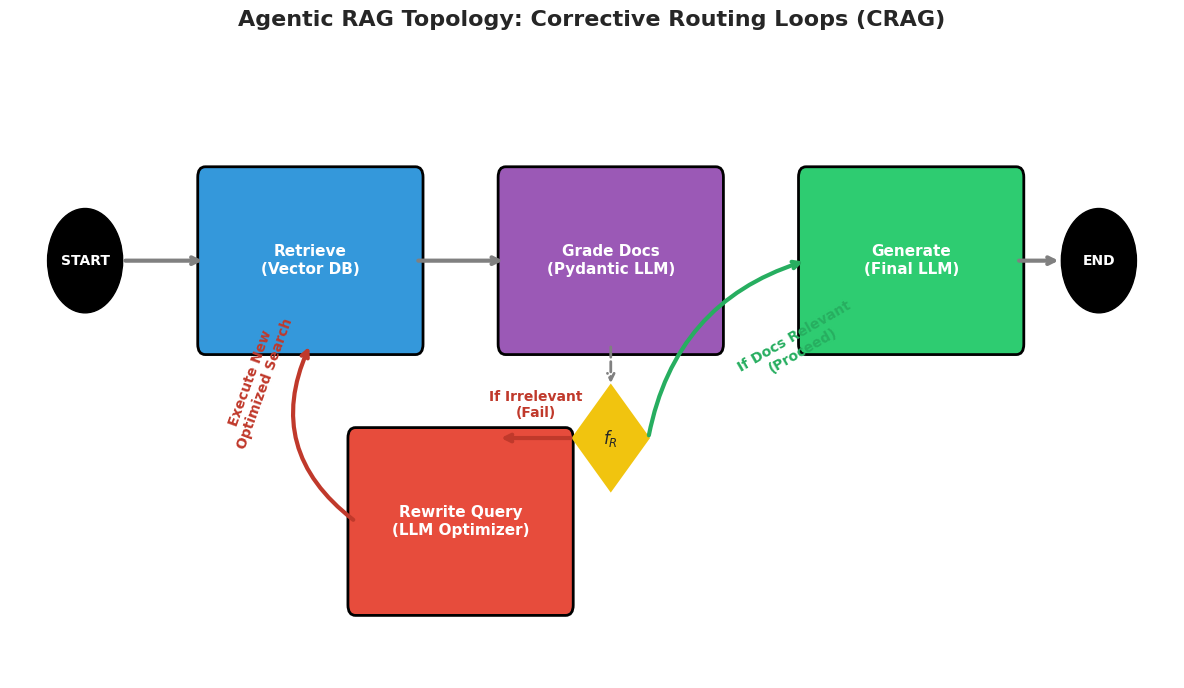

In [10]:
# Visualizing the CRAG Graph Topology
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Agentic RAG Topology: Corrective Routing Loops (CRAG)", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Node Coordinates
nodes = {
    "__START__": (1, 4, "black", "white", "circle"),
    "Retrieve\n(Vector DB)": (4, 4, "#3498db", "white", "box"),
    "Grade Docs\n(Pydantic LLM)": (8, 4, "#9b59b6", "white", "box"),
    "Generate\n(Final LLM)": (12, 4, "#2ecc71", "white", "box"),
    "__END__": (14.5, 4, "black", "white", "circle"),
    "Rewrite Query\n(LLM Optimizer)": (6, 1.5, "#e74c3c", "white", "box")
}

# Draw Nodes
for name, (x, y, color, text_color, shape) in nodes.items():
    if shape == "circle":
        circle = patches.Circle((x, y), 0.5, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name.strip("_"), color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)
    else:
        rect = patches.FancyBboxPatch((x-1.4, y-0.8), 2.8, 1.6, boxstyle="round,pad=0.1", 
                                     linewidth=2, edgecolor='black', facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=11, zorder=4)

# 2. Draw the Static Edges
ax.annotate("", xy=(2.6, 4), xytext=(1.5, 4), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.annotate("", xy=(6.6, 4), xytext=(5.4, 4), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.annotate("", xy=(14, 4), xytext=(13.4, 4), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# 3. Draw the Conditional Routing Edges
# Router Box
router_box = patches.Polygon([[8, 2.8], [8.5, 2.3], [8, 1.8], [7.5, 2.3]], closed=True, fill=True, color='#f1c40f', edgecolor='black', linewidth=2, zorder=3)
ax.add_patch(router_box)
ax.text(8, 2.3, "$f_R$", ha='center', va='center', fontweight='bold', fontsize=12, zorder=4)

# Grader to Router
ax.annotate("", xy=(8, 2.8), xytext=(8, 3.2), arrowprops=dict(arrowstyle="->", lw=2, color="gray", linestyle="--"))

# Route: Success -> Generate
ax.annotate("", xy=(10.6, 4), xytext=(8.5, 2.3), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", connectionstyle="arc3,rad=-0.3"))
ax.text(10.5, 2.8, "If Docs Relevant\n(Proceed)", ha='center', fontsize=10, fontweight='bold', color="#27ae60", rotation=30)

# Route: Failure -> Rewrite Query
ax.annotate("", xy=(6.5, 2.3), xytext=(7.5, 2.3), arrowprops=dict(arrowstyle="->", lw=3, color="#c0392b"))
ax.text(7, 2.5, "If Irrelevant\n(Fail)", ha='center', fontsize=10, fontweight='bold', color="#c0392b")

# The Backward Loop: Rewrite -> Retrieve
ax.annotate("", xy=(4, 3.2), xytext=(4.6, 1.5), arrowprops=dict(arrowstyle="->", lw=3, color="#c0392b", connectionstyle="arc3,rad=-0.4"))
ax.text(3.3, 2.2, "Execute New\nOptimized Search", ha='center', fontsize=10, fontweight='bold', color="#c0392b", rotation=70)

plt.xlim(0, 15.5)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Agentic RAG like **A Junior Lawyer reporting to a Senior Partner**:

* **Standard Linear RAG**: The Senior Partner (User) asks the Junior Lawyer (The LLM) for case law regarding a specific corporate merger. The Junior Lawyer goes to the filing room (Vector DB), grabs the first 3 files they see, walks back to the Partner, and summarizes them. The files happen to be about a divorce case. The Junior Lawyer summarizes the divorce case anyway, wasting the Partner's time (Hallucination).
* **Agentic RAG (CRAG)**: The Junior Lawyer goes to the filing room and grabs 3 files (Retrieve). Before walking back to the Partner, the Junior Lawyer sits at a desk and *reads* the files (Grader Node). They realize, *"Wait, these are about a divorce, not a corporate merger. This is useless."* * Instead of presenting garbage to the Partner, the Junior Lawyer physically stays in the file room, realizes their search term was bad, rewrites their search strategy (Rewriter Node), and searches the filing cabinets a second time (The Cyclic Loop). They only present the summary (Generate Node) once they have mathematically verified the files are correct.